In [ ]:
# Helper cell for folder setup and type checking. Only run if the kernel is Sage.

import os, sys
print(os.getcwd(), sys.executable)

%cd /mnt/d/Projects/m2-bezout/internship/src/symbolic
from utils import styled_print

from typing import TYPE_CHECKING
if TYPE_CHECKING:
    from type_checking import *

/home/chocomint /home/chocomint/miniconda3/envs/sage/bin/python3
/mnt/d/Projects/m2-bezout/internship/src/symbolic


#### Check asymptotics of $y_{n+2} = \dfrac{a}{n}\sum\limits_{i=1}^n y_i + b$.

In [12]:
x,y=var('x y',domain=RR)
z=x+I*y

a = var('a')
y1 = var('y_1')
Y = function('Y')(z)

In [5]:
ode = diff(Y, z) - (2/z + a*z/(1-z)) * Y == -y1
sol = desolve(ode, Y, ivar=z).canonicalize_radical()
show(sol)
styled_print(sol)

-(y_1*integrate((z - 1)^a*e^(a*z)/z^2, z) - _C)*z^2*e^(-a*z)/(z - 1)^a

<IPython.core.display.Math object>

In [16]:
z, a, y1 = var('z a y_1')
Y = function('Y')(z)
ode = diff(Y,z) - (2/z + a*z/(1-z))*Y == -y1

mu = z^(-2) * (1 - z)^a * exp(a*z)
C = var('C')
sol_1mz = Y == (C - y1*integral(mu, z))/mu
styled_print(sol_1mz)

<IPython.core.display.Math object>

#### Compute distribution of $Y_n$

$$Y_{n+2} = I\left(Y_{U_n}^{(1)} + Y_{n+1-U_n}^{(2)} + 1\right) + J\max\left(Y_{U_n}^{(1)}, Y_{n+1-U_n}^{(2)}\right).$$

In [ ]:
def compute_exact_distributions(max_N, a, b):
    pmf = [[0.0] * (max_N + 1) for _ in range(max_N + 1)]
    cdf = [[0.0] * (max_N + 1) for _ in range(max_N + 1)]
    
    pmf[0][0] = 1.0
    pmf[1][0] = 1.0
    pmf[2][0] = 1.0
    
    for i in range(3):
        for k in range(max_N + 1):
            cdf[i][k] = 1.0

    termination_prob = 1.0 - a - b

    for N_target in range(3, max_N + 1):
        n = N_target - 2
        
        for k in range(N_target):
            prob_k = 0.0
            
            for u in range(1, n + 1):
                v = n + 1 - u
                
                c_prob = 0.0
                if k >= 1:
                    for j in range(k):
                        c_prob += pmf[u][j] * pmf[v][k - 1 - j]
                        
                cdf_u_k = cdf[u][k]
                cdf_v_k = cdf[v][k]
                cdf_u_k_minus_1 = cdf[u][k - 1] if k > 0 else 0.0
                cdf_v_k_minus_1 = cdf[v][k - 1] if k > 0 else 0.0
                
                m_prob = (cdf_u_k * cdf_v_k) - (cdf_u_k_minus_1 * cdf_v_k_minus_1)
                
                # Accumulate the conditional probabilities based on the split
                prob_k += a * c_prob + b * m_prob
                
            # Divide by n to account for the uniform split, then add the independent termination term
            t_prob = 1.0 if k == 0 else 0.0
            pmf[N_target][k] = (prob_k / n) + (termination_prob * t_prob)
            
        current_cdf = 0.0
        for k in range(max_N + 1):
            if k < N_target:
                current_cdf += pmf[N_target][k]
            cdf[N_target][k] = current_cdf

    expected_values = []
    for i in range(1, max_N + 1):
        expected_y = sum(k * pmf[i][k] for k in range(i))
        expected_values.append(expected_y)

    return pmf, cdf, expected_values

In [1]:
import numpy as np

def compute_exact_distributions_optimized(max_N, a, b):
    # Store variable-length PMF and CDF arrays to save memory for small trees
    pmfs = [np.array([1.0]), np.array([1.0]), np.array([1.0])]
    cdfs = [np.array([1.0]), np.array([1.0]), np.array([1.0])]
    
    termination_prob = 1.0 - a - b

    for N_target in range(3, max_N + 1):
        n = N_target - 2
        # The maximum possible value for Y_N is N - 1
        current_pmf = np.zeros(N_target)
        
        # Exploit symmetry: evaluate up to n // 2 and double the weights
        for u in range(1, (n // 2) + 1):
            v = n + 1 - u
            weight = 2.0 if u != v else 1.0
            
            # --- 1. Concatenation Term ---
            # Compute discrete convolution of PMFs
            conv_pmf = np.convolve(pmfs[u], pmfs[v])
            
            # Shift by 1 to account for the "+ 1" in the formula
            concat_pmf = np.zeros(len(conv_pmf) + 1)
            concat_pmf[1:] = conv_pmf
            
            length_c = min(len(concat_pmf), N_target)
            current_pmf[:length_c] += weight * a * concat_pmf[:length_c]
            
            # --- 2. Alternation Term ---
            # Max of two variables: CDF_max = CDF_u * CDF_v
            len_u = len(cdfs[u])
            len_v = len(cdfs[v])
            max_len = max(len_u, len_v)
            
            cdf_u_ext = np.ones(max_len)
            cdf_u_ext[:len_u] = cdfs[u]
            
            cdf_v_ext = np.ones(max_len)
            cdf_v_ext[:len_v] = cdfs[v]
            
            cdf_max = cdf_u_ext * cdf_v_ext
            
            # PMF is the backward difference of the CDF
            pmf_max = np.zeros(max_len)
            pmf_max[0] = cdf_max[0]
            pmf_max[1:] = cdf_max[1:] - cdf_max[:-1]
            
            length_m = min(len(pmf_max), N_target)
            current_pmf[:length_m] += weight * b * pmf_max[:length_m]
            
        # Average over the uniform choice of U_n
        current_pmf /= n
        
        # --- 3. Termination Term ---
        current_pmf[0] += termination_prob
        
        # Correct minor floating-point inaccuracies from repeated array operations
        current_pmf = np.maximum(current_pmf, 0)
        current_pmf /= np.sum(current_pmf)
        
        pmfs.append(current_pmf)
        cdfs.append(np.cumsum(current_pmf))

    # Compute expected values using dot product
    expected_values = [np.sum(np.arange(len(p)) * p) for p in pmfs[1:]]
    
    return pmfs, cdfs, expected_values

In [69]:
MAX_SIZE = 1000

# 2a+b < 1
pmf1, cdf1, expectations1 = compute_exact_distributions_optimized(MAX_SIZE, 0.4, 0.1)
# 2a+b = 1
pmf2, cdf2, expectations2 = compute_exact_distributions_optimized(MAX_SIZE, 0.4, 0.2)
# 2a+b > 1
pmf3, cdf3, expectations3 = compute_exact_distributions_optimized(MAX_SIZE, 0.5, 0.3)

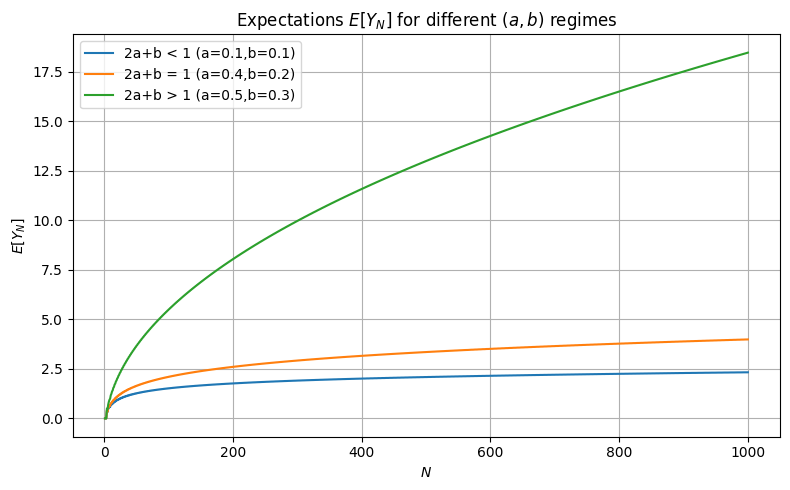

In [7]:
import matplotlib.pyplot as plt

# Plot the computed expectations for the three regimes on one figure
min_len = min(len(expectations1), len(expectations2), len(expectations3))
x = list(range(1, min_len + 1))
plt.figure(figsize=(8,5))
plt.plot(x, expectations1[:min_len], label='2a+b < 1 (a=0.1,b=0.1)')
plt.plot(x, expectations2[:min_len], label='2a+b = 1 (a=0.4,b=0.2)')
plt.plot(x, expectations3[:min_len], label='2a+b > 1 (a=0.5,b=0.3)')
plt.xlabel('$N$')
plt.ylabel('$E[Y_N]$')
plt.title('Expectations $E[Y_N]$ for different $(a,b)$ regimes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Solve $\alpha + 1 = a + b(1-2^{-\alpha})$

In [57]:
def solve_alpha(a, b, initial_guess=0.0, tolerance=1e-10, max_iterations=10000):
    """
    Solves alpha + 1 = a + b(1 - 2^{-alpha+1}) using fixed-point iteration.
    """
    alpha = initial_guess
    
    for i in range(max_iterations):
        # The iteration function: f(alpha) = a + b(1 - 2^-alpha) - 1
        next_alpha = a + b * (1 - 2**(-alpha)) - 1
        
        # Check for convergence
        if abs(next_alpha - alpha) < tolerance:
            return next_alpha
        
        alpha = next_alpha
        
    raise RuntimeError("Convergence not reached within the maximum number of iterations.")

In [20]:
a = 1.3
b = 0.3
alpha = solve_alpha(a, b)
alpha + 1 - a - b*(1 - 2**(-alpha))

-2.8852892297592803e-12

Text(0.5, 0, '$N$')

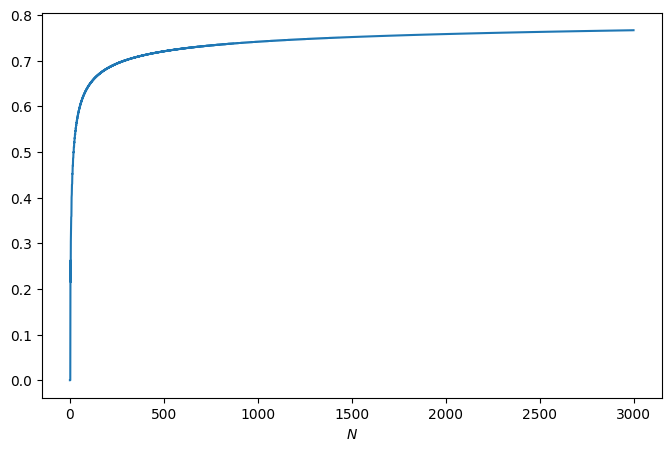

In [9]:
import matplotlib.pyplot as plt

MAX_SIZE = 3000
u = 0.5
v = 0.3

pmf4, cdf4, expectations4 = compute_exact_distributions_optimized(MAX_SIZE, u, v)

alpha = solve_alpha(2*u+v, v)

normalized = [expectations4[i] / (i+1)**alpha for i in range( MAX_SIZE)]

plt.figure(figsize=(8,5))
plt.plot(normalized, label='Normalized $E[Y_N]$ (u=0.5,v=0.3)')
plt.xlabel('$N$')

Text(0.5, 0, '$N$')

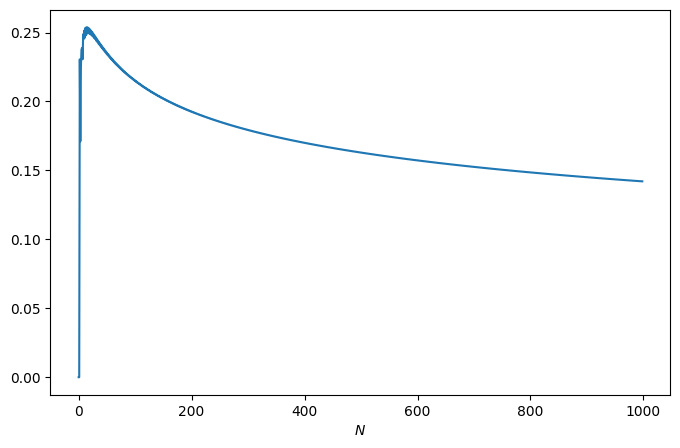

In [60]:
import matplotlib.pyplot as plt

MAX_SIZE = 1000
u = 0.5
v = 0.3

pmf4, cdf4, expectations4 = compute_exact_distributions_optimized(MAX_SIZE, u, v)

alpha = solve_alpha(2*u+2*v, v/2)
test_alpha = alpha+0.05

normalized = [expectations4[i] / i**test_alpha for i in range(1, MAX_SIZE)]

plt.figure(figsize=(8,5))
plt.plot(normalized, label='Normalized $E[Y_N]$ (u=0.5,v=0.3)')
plt.xlabel('$N$')

In [26]:
alpha

0.46545414418368225

In [27]:
2*(u+v) - 1

0.6000000000000001

In [18]:
normalized[1900:]

[np.float64(0.7569445813601124),
 np.float64(0.7570546117260784),
 np.float64(0.7569680241008869),
 np.float64(0.757077842537118),
 np.float64(0.7569912442419725),
 np.float64(0.7571010421340002),
 np.float64(0.7570146237774763),
 np.float64(0.7571242104326298),
 np.float64(0.7570377812692545),
 np.float64(0.7571473476694077),
 np.float64(0.7570610975246838),
 np.float64(0.7571704537603756),
 np.float64(0.7570841930569234),
 np.float64(0.7571935289404105),
 np.float64(0.7571074467239192),
 np.float64(0.7572165731263341),
 np.float64(0.7571304802149837),
 np.float64(0.757239586551508),
 np.float64(0.7571536712191225),
 np.float64(0.7572625691328897),
 np.float64(0.7571766433498208),
 np.float64(0.7572855211023424),
 np.float64(0.7571997723721794),
 np.float64(0.75730844237759),
 np.float64(0.7572226830629415),
 np.float64(0.7573313331890071),
 np.float64(0.7572457500295103),
 np.float64(0.757354193454453),
 np.float64(0.7572685999522993),
 np.float64(0.7573770234028279),
 np.float64(0.7

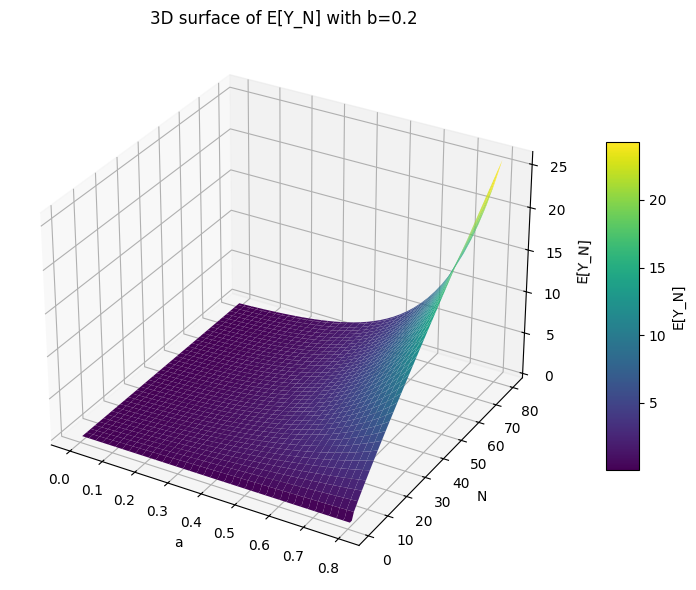

In [11]:
# 3D surface: fix b and vary a and n
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Parameters -- adjust as needed
b_fixed = 0.2
a_vals = np.linspace(0.0, 1.0 - b_fixed - 1e-8, 40)
N_max_3d = 80

# Compute expectations for each 'a' on the grid (this may be slow for large N_max_3d or many a_vals)
Z = np.zeros((len(a_vals), N_max_3d))
for i, a_val in enumerate(a_vals):
    _, _, expectations = compute_exact_distributions(N_max_3d, float(a_val), float(b_fixed))
    Z[i, :] = expectations[:N_max_3d]

# Prepare mesh for plotting: meshgrid with shape (N_max_3d, len(a_vals))
N_seq = np.arange(1, N_max_3d + 1)
A_mesh, N_mesh = np.meshgrid(a_vals, N_seq)
Z_plot = Z.T

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(A_mesh, N_mesh, Z_plot, cmap='viridis', edgecolor='none')
ax.set_xlabel('a')
ax.set_ylabel('N')
ax.set_zlabel('E[Y_N]')
ax.set_title(f'3D surface of E[Y_N] with b={b_fixed}')
fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10, label='E[Y_N]')
plt.tight_layout()
plt.show()

Computing heatmap grid: 50 a-values × N_max=200


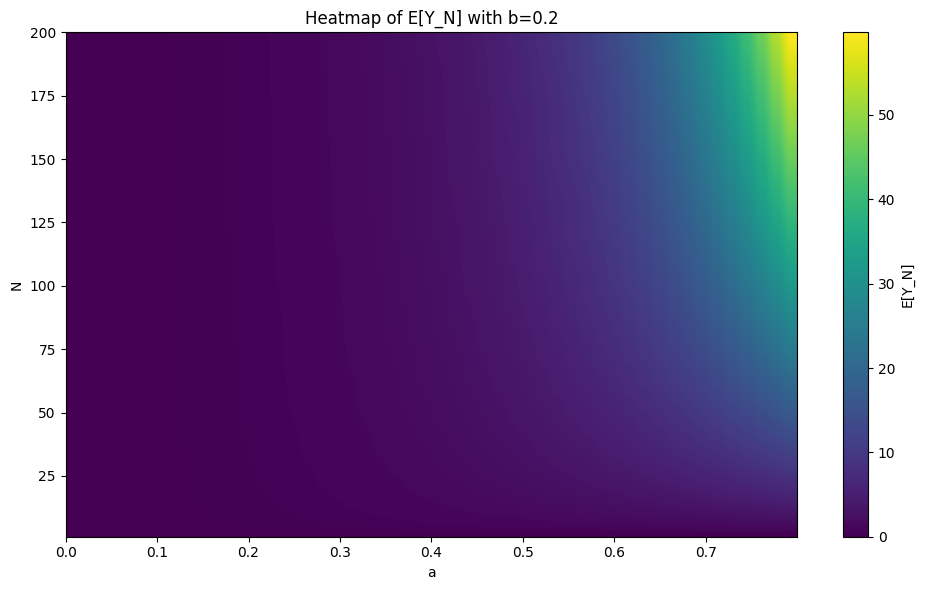

In [13]:
# Heatmap: fix b and vary a and n (moderate resolution by default)
import numpy as np
import matplotlib.pyplot as plt

# Parameters (tune these if you need more resolution)
b_fixed = 0.2
a_vals = np.linspace(0.0, 1.0 - b_fixed - 1e-8, 50)
N_max_heatmap = 200

print(f'Computing heatmap grid: {len(a_vals)} a-values × N_max={N_max_heatmap}')
# Compute expectations grid: Z[n-1, i] = E[Y_n] for a = a_vals[i]
Z = np.zeros((N_max_heatmap, len(a_vals)))
for i, a_val in enumerate(a_vals):
    _, _, expectations = compute_exact_distributions(N_max_heatmap, float(a_val), float(b_fixed))
    Z[:, i] = expectations[:N_max_heatmap]

# Plot heatmap with axis: a (x), N (y)
plt.figure(figsize=(10,6))
im = plt.imshow(Z, aspect='auto', origin='lower', extent=[a_vals[0], a_vals[-1], 1, N_max_heatmap], cmap='viridis')
plt.colorbar(im, label='E[Y_N]')
plt.xlabel('a')
plt.ylabel('N')
plt.title(f'Heatmap of E[Y_N] with b={b_fixed}')
plt.tight_layout()
plt.show()

#### Experiment with the sequence containing a difference 

$$y_{n+2} = \dfrac{a}{n}\sum_{i=1}^n y_n + \dfrac{b}{n}\sum_{i=1}^n |y_{n+1-i} - y_i| + c.$$

We want to see when $a>1$, $\lim \dfrac{y_n}{n^{a-1}}\to\infty$.
Let $P_k = \sum_{i=1}^k y_k$, we have
$$y_{n+2} = \dfrac{a}{n} P_n + \dfrac{2b}{n}\left|P_{\lfloor n/2\rfloor} + P_{n-\lfloor n/2\rfloor} - P_n\right| + c.$$
That gives an optimized implementation.

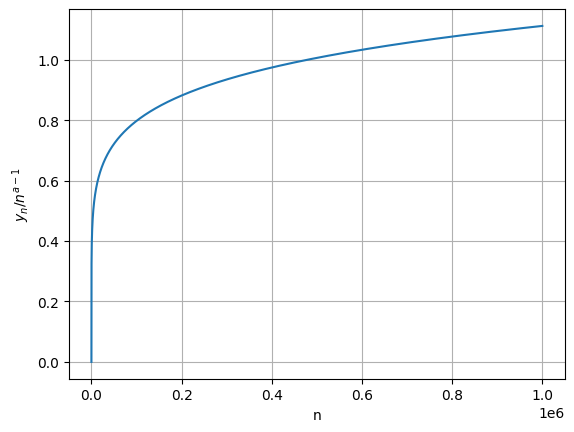

In [67]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000000
a = 1.5
b = 0.2
c = 0.1

Y = np.zeros(N)
Y[0] = Y[1] = 0
P = np.zeros(N + 1) 

for n in range(2, N):
    m = n // 2
    
    S_n = 2.0 * abs(P[m] + P[n - m] - P[n])
    y = (a / n) * P[n] + (b / n) * S_n + c
    Y[n] = y
    P[n + 1] = P[n] + y

n_vals = np.arange(1, N)
normalized = Y[1:] / np.power(n_vals, a-1)

plt.plot(n_vals, normalized) 
plt.xlabel('n')
plt.ylabel(r'$y_n / n^{a-1}$')
plt.grid(True)
plt.show()

In [5]:
Y

array([0.        , 0.        , 0.1       , 0.15      , 0.19375   ,
       0.225125  , 0.25388542, 0.27773438, 0.30009277, 0.31926459,
       0.33747782, 0.35372227, 0.36928987, 0.38337377, 0.39695468,
       0.40944692, 0.42154877, 0.43276861, 0.44367679, 0.4538943 ,
       0.46385636, 0.47323432, 0.48239914, 0.49108221, 0.49958438,
       0.50766743, 0.51559504, 0.52316719, 0.53060412, 0.5377255 ,
       0.5447282 , 0.55145676, 0.55808018, 0.56445657, 0.57073918,
       0.57680381, 0.58278421, 0.58856587, 0.59427146, 0.5997991 ,
       0.60525764, 0.61055243, 0.61578418, 0.62086787, 0.62589378,
       0.63078239, 0.63561785, 0.64032798, 0.64498905, 0.64953314,
       0.6540318 , 0.65842296, 0.66277189, 0.66701996, 0.6712287 ,
       0.67534411, 0.67942278, 0.68341347, 0.68736977, 0.69124425,
       0.69508645, 0.69885124, 0.70258566, 0.70624773, 0.70988118,
       0.71344593, 0.71698367, 0.72045694, 0.72390468, 0.72729101,
       0.73065315, 0.73395744, 0.73723879, 0.7404649 , 0.74366

#### Experiment with 

$$nx_{n+2} - (n-1)x_{n+1} = (a+b)x_n - bx_{\lfloor n/2\rfloor} + c.$$

##### Check asymptotic

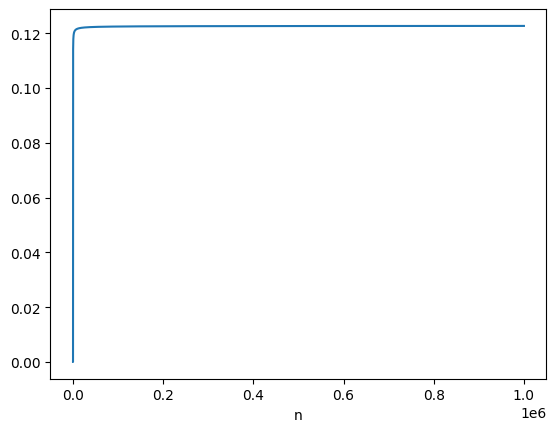

In [68]:
a = 1.5
b = 0.2
c = 0.1

alpha = solve_alpha(a, b)

N = 1000000

X = np.zeros(N+1)

for n in range(3, N+1):
    xn = ((n-3) * X[n-1] + (a+b)* X[n-2] - b*X[(n+2)//2] + c)/(n-2)
    X[n] = xn

normalized = X[1:] / np.power(np.arange(1, N+1), alpha)

plt.plot(normalized)
plt.xlabel('n')
plt.show()

##### Check concentration

[0.00017006 0.00016995 0.00016984 0.00016972 0.00016961]


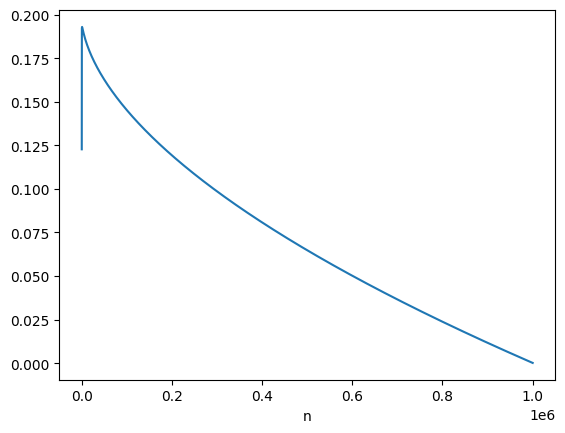

In [56]:
a = 1.5
b = 0.2
c = 0.1

alpha = solve_alpha(a, b)

N = 1000000

X = np.zeros(N+1)

for n in range(3, N+1):
    xn = ((n-3) * X[n-1] + (a+b)* X[n-2] - b*X[(n+2)//2] + c)/(n-2)
    X[n] = xn

D = X[-1]/(N-1)**alpha

concentrations = np.power(np.arange(1, N+1), alpha) * D - X[1:]

print(concentrations[-5:])

plt.plot(concentrations)
plt.xlabel('n')
plt.show()

##### Check monotonicity

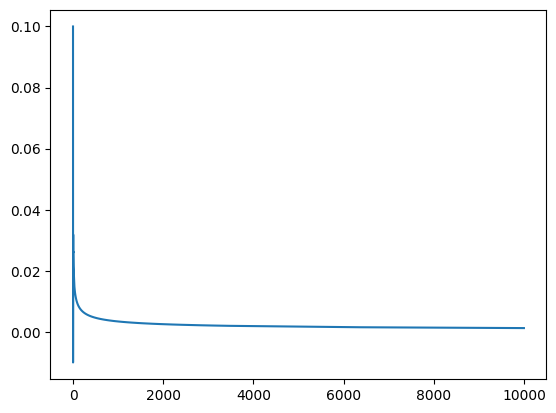

In [7]:
import numpy as np
from matplotlib import pyplot as plt

a = 1.5
b = 0.2
c = 0.1

N = 10000

X = np.zeros(N+1)

for n in range(3, N+1):
    xn = ((n-3) * X[n-1] + (a+b)* X[n-2] - b*X[(n+2)//2] + c)/(n-2)
    X[n] = xn

diffs = X[3:] - X[2:-1]

plt.plot(diffs)
# plt.plot(X[1:])

##### Check if the true $\alpha$ is closer to the lower or upper bound

In [28]:
u = 0.4
v = 0.6
alpha = solve_alpha(2*u+v, v)

print("Distance to lower bound:", alpha - 2*u - v + 1)
print("Distance to upper bound:", 2*(u+v) - 1 - alpha)

Distance to lower bound: 0.20571173767959372
Distance to upper bound: 0.39428826232040626
